# Anotações: Introdução à Teoria das Probabilidades
**Baseado em:** Material de Francisco A. Rodrigues (Universidade de São Paulo)

Resumo pessoal dos principais conceitos introdutórios de probabilidade, complementado com scripts de simulação práticos construídos em Python.

## 1. Teoria dos Conjuntos e Conceitos Básicos
Para a formulação matemática da probabilidade, utilizamos a teoria dos conjuntos. 

- **União ($A \cup B$):** O evento ocorre se $A$ ou $B$ (ou ambos) ocorrem.
- **Intersecção ($A \cap B$):** O evento ocorre se $A$ e $B$ ocorrem simultaneamente.
- **Complementar ($\overline{A}$ ou $A^c$):** O evento ocorre se $A$ não ocorre.

**Eventos Mutuamente Exclusivos:** Diz-se que os eventos $A$ e $B$ são mutuamente exclusivos se $A \cap B = \emptyset$.

## 2. Experimento Aleatório e Eventos

- **Experimento Aleatório:** Um experimento com resultado incerto, mas que pode ser repetido inúmeras vezes sob as mesmas condições (ex: lançamento de um dado). Não é possível prever o próximo valor, mas é possível calcular as probabilidades associadas.
- **Espaço Amostral ($\Omega$):** Representa o conjunto de *todas as saídas possíveis*.
- **Evento ($A$):** É um subconjunto do espaço amostral.

Exemplo computacional de sorteio aleatório (simulação de lançamento de moeda):

In [2]:
import numpy as np

moeda = ['cara',  'coroa']
n = 5 # quantidade de vezes para repetir o experimento aleatório

print("Resultados de simulações do experimento aleatório:")
for i in range(0,n):
    face = np.random.choice(moeda)
    print(f'Face sorteada {i+1}:', face)

Resultados de simulações do experimento aleatório:
Face sorteada 1: cara
Face sorteada 2: cara
Face sorteada 3: coroa
Face sorteada 4: coroa
Face sorteada 5: cara


## 3. As Abordagens e Axiomas da Probabilidade

### 3.1 Axiomas de Probabilidade
Uma função $P(\cdot)$ é probabilidade se satisfaz:
1. $0 \leq P(A) \leq 1$, para todo $A \subset \Omega$
2. $P(\Omega) = 1$
3. Se $A_1, A_2, \dots$ são mutuamente exclusivos, $P(\cup_{i=1}^{\infty} A_i) = \sum_{i=1}^{\infty} P(A_i)$

### 3.2 Probabilidade Clássica
Se temos $n(\Omega)$ resultados mutuamente exclusivos e *igualmente possíveis*, a probabilidade de $A$ é dada por:

$$P(A) = \frac{n(A)}{n(\Omega)} = \frac{|A|}{|\Omega|}$$

**Simulação de probabilidade clássica (ex: calcular a probabilidade de sortear uma ficha > 9 em uma urna de 1 a 20):**

In [5]:
import random
import numpy as np

n = 20
urna = np.arange(1,n+1)
valor = 9
f = 0 # contador

ns = 100
for i in range(0,ns):
  ficha = random.choice(urna)
  if(ficha > valor):
    f = f + 1
print('Frequencia simulada:', f/ns)
print('Probabilidade exata (clássica):', len(range(valor+1, n+1))/n)

Frequencia simulada: 0.6
Probabilidade exata (clássica): 0.55


### 3.3 Probabilidade Frequentista
A probabilidade computada como o limite da frequência relativa de um evento em um grande número de experimentos:

$$P(A) = \lim_{n \to \infty} \frac{n_A}{n}$$

Na prática, com poucos lançamentos, as frequências desviam muito do comportamento real, mas graças à lei dos grandes números convergem para a probabilidade teórica, como demonstrado abaixo.

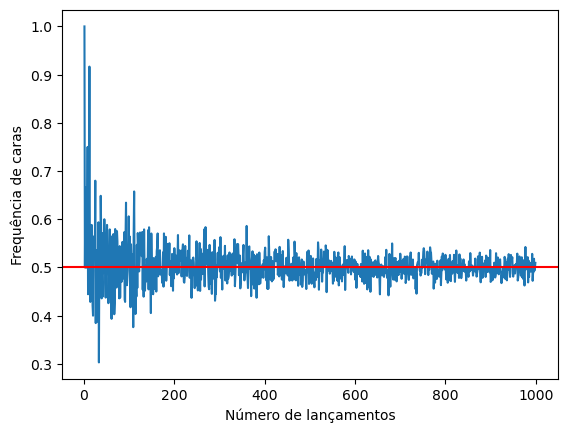

In [6]:
import numpy as np
import matplotlib.pyplot as plt

moeda = ['cara',  'coroa']
p = 0.5 # A probabilidade teórica
lcaras = [] # Guardará a frquência simulada
ln = []     # Guardará o passo da iteração
for n in range(1,1000):
  ncaras = 0
  for i in range(0,n):
    face = np.random.choice(moeda)
    if face == 'cara':
      ncaras = ncaras + 1
  fa = ncaras/n
  lcaras.append(fa)
  ln.append(n)

# Plotando como as amostras convergem para a linha vermelha teórica (p)
plt.plot(ln, lcaras)
plt.axhline(y=p, color='r', linestyle='-')
plt.xlabel('Número de lançamentos')
plt.ylabel('Frequência de caras')
plt.show()

## 4. Teoremas Importantes

- **União de dois eventos:** 
  $$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$
  *(Subtraindo a interseção para não contar dobrado)*.

- **Outras propriedades:**
  1. $P(\emptyset) = 0$
  2. $P(A) = 1 - P(A^c)$
  3. Se $A \subset B$, então $P(A) \leq P(B)$